# CIND820 Milestone 3 — Notebook 05: Held-Out Test Evaluation
**Student:** Mubarak Ahmed (501345730)
**Pipeline Stage:** Initial results on the held-out test set

**Purpose:** Evaluate the champion (XGBoost + class weights) and baseline (Logistic Regression +
class weights) — both fitted in Notebook 04 on the training split only — against the 2,065-row
held-out test set that no model, transformation, or selection step has touched.

Contents:
1. Test-set macro-F1 and AUPRC vs cross-validation means (generalization check)
2. Confusion matrices (counts and row-normalized)
3. Per-class precision / recall / F1
4. Wilcoxon signed-rank test on paired fold scores (champion vs baseline)
5. Weakness analysis and next steps

In [1]:
# Section 1: Load test data and fitted models
import sys
sys.path.append('../src')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import (f1_score, average_precision_score,
                             confusion_matrix, classification_report)
from sklearn.preprocessing import label_binarize
from scipy.stats import wilcoxon

test = pd.read_parquet('../data/processed/X_test.parquet')
X_test = test.drop(columns=['delay_class'])
y_test = test['delay_class']

champion = joblib.load('../outputs/models/xgboost_champion.joblib')
baseline = joblib.load('../outputs/models/logreg_baseline.joblib')
CLASS_NAMES = ['On-time (0)', 'At-risk (1)', 'Delayed (2)']
print(f"Test matrix: {X_test.shape} | class counts: {y_test.value_counts().sort_index().tolist()}")

Test matrix: (2065, 154) | class counts: [1828, 138, 99]


## Section 2: Test-set performance vs cross-validation estimates

If the CV protocol is sound, test scores should land near the CV means. A large gap in either
direction would indicate leakage (test ≫ CV) or overfitting to the folds (test ≪ CV).

In [2]:
# Score both models on the untouched test set
rows = []
for name, model in [('XGBoost (champion)', champion), ('LogisticRegression (baseline)', baseline)]:
    proba = model.predict_proba(X_test)
    pred = np.argmax(proba, axis=1)
    y_bin = label_binarize(y_test, classes=[0, 1, 2])
    rows.append({
        'model': name,
        'test_macro_f1': round(f1_score(y_test, pred, average='macro'), 4),
        'test_auprc_macro': round(average_precision_score(y_bin, proba, average='macro'), 4),
    })

# Pull CV means for comparison from Notebook 04's saved results
cv_summary = pd.read_csv('../outputs/tables/cv_summary.csv')
cw = cv_summary[cv_summary.strategy == 'class_weight'].set_index('model')
test_results = pd.DataFrame(rows)
test_results['cv_macro_f1_mean'] = [cw.loc['XGBoost', 'macro_f1_mean'],
                                    cw.loc['LogisticRegression', 'macro_f1_mean']]
test_results['generalization_gap'] = (test_results['test_macro_f1']
                                      - test_results['cv_macro_f1_mean']).round(4)
test_results.to_csv('../outputs/tables/test_metrics_summary.csv', index=False)
test_results

,model,test_macro_f1,test_auprc_macro,cv_macro_f1_mean,generalization_gap
0,XGBoost (champion),0.5927,0.5897,0.5781,0.0146
1,LogisticRegression (baseline),0.3779,0.4388,0.3688,0.0091


## Section 3: Confusion matrices — where do the errors live?

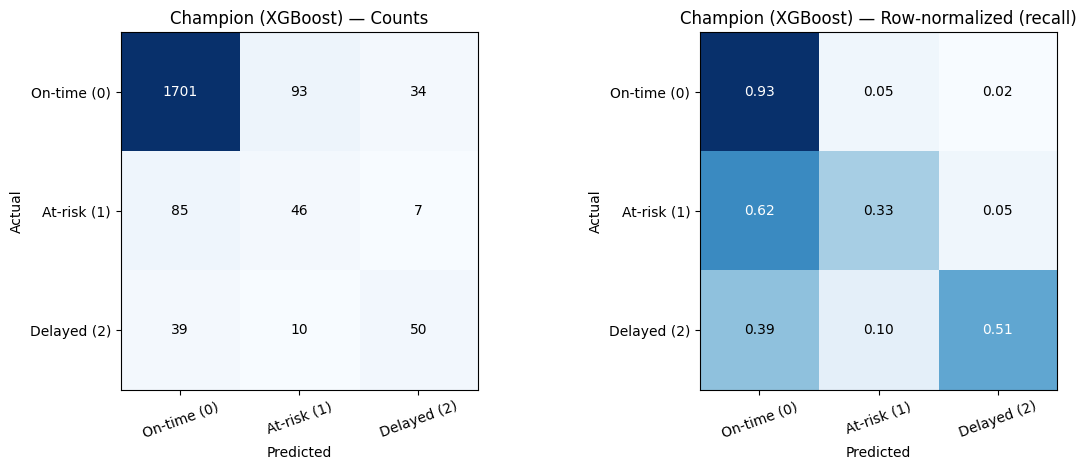

Figure saved to outputs/figures/confusion_matrix_champion.png


In [3]:
# Confusion matrices for the champion: raw counts and row-normalized (recall view)
pred_champ = champion.predict(X_test)
cm = confusion_matrix(y_test, pred_champ)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, mat, title, fmt in [(axes[0], cm, 'Counts', 'd'),
                            (axes[1], cm_norm, 'Row-normalized (recall)', '.2f')]:
    im = ax.imshow(mat, cmap='Blues')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(CLASS_NAMES, rotation=20); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Champion (XGBoost) — {title}')
    for i in range(3):
        for j in range(3):
            v = mat[i, j]
            ax.text(j, i, format(v, fmt), ha='center', va='center',
                    color='white' if v > mat.max()/2 else 'black')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix_champion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to outputs/figures/confusion_matrix_champion.png")

## Section 4: Per-class precision, recall, and F1

In [4]:
# Classification report as a saved artifact
report = pd.DataFrame(classification_report(
    y_test, pred_champ, target_names=CLASS_NAMES, output_dict=True)).T.round(3)
report.to_csv('../outputs/tables/test_classification_report_champion.csv')
report

,precision,recall,f1-score,support
On-time (0),0.932,0.931,0.931,1828.00
At-risk (1),0.309,0.333,0.321,138.00
Delayed (2),0.549,0.505,0.526,99.00
accuracy,0.870,0.870,0.870,0.87
macro avg,0.597,0.590,0.593,2065.00
weighted avg,0.872,0.870,0.871,2065.00


## Section 5: Statistical comparison — Wilcoxon signed-rank test

**Design:** the champion and baseline were evaluated on the *same* five CV folds (Notebook 04),
giving five paired macro-F1 scores. The Wilcoxon signed-rank test is used instead of a paired
t-test because with n = 5 fold-level scores, normality of the differences cannot be assumed.

**One-sided alternative, stated in advance:** H₁ = champion macro-F1 > baseline macro-F1
(the research hypothesis in RQ2 is directional). Note a two-sided Wilcoxon with n = 5 pairs
cannot reach p < 0.05 (its minimum attainable p is 0.0625); the one-sided minimum is 0.03125,
attained only when all five folds favor the champion.

In [5]:
# Paired fold scores from Notebook 04's saved per-fold results
per_fold = pd.read_csv('../outputs/tables/cv_results_per_fold.csv')
champ_scores = per_fold[(per_fold.model == 'XGBoost') &
                        (per_fold.strategy == 'class_weight')].sort_values('fold')['macro_f1'].values
base_scores = per_fold[(per_fold.model == 'LogisticRegression') &
                       (per_fold.strategy == 'class_weight')].sort_values('fold')['macro_f1'].values

diffs = champ_scores - base_scores
stat, p_value = wilcoxon(champ_scores, base_scores, alternative='greater')

print("Paired per-fold macro-F1:")
for i, (c, b) in enumerate(zip(champ_scores, base_scores), 1):
    print(f"  Fold {i}: champion {c:.4f} | baseline {b:.4f} | diff +{c-b:.4f}")
print(f"\nMean difference: +{diffs.mean():.4f} macro-F1")
print(f"Wilcoxon signed-rank (one-sided, H1: champion > baseline): W = {stat}, p = {p_value:.5f}")
print(f"Folds favoring champion: {(diffs > 0).sum()} of 5")

pd.DataFrame([{'test': 'Wilcoxon signed-rank (one-sided)',
               'W': stat, 'p_value': p_value, 'n_pairs': 5,
               'mean_diff_macro_f1': round(diffs.mean(), 4)}]).to_csv(
    '../outputs/tables/wilcoxon_champion_vs_baseline.csv', index=False)
print("\nSaved to outputs/tables/wilcoxon_champion_vs_baseline.csv")

Paired per-fold macro-F1:
  Fold 1: champion 0.5768 | baseline 0.3597 | diff +0.2170
  Fold 2: champion 0.5855 | baseline 0.3693 | diff +0.2162
  Fold 3: champion 0.5482 | baseline 0.3604 | diff +0.1879
  Fold 4: champion 0.5885 | baseline 0.3712 | diff +0.2173
  Fold 5: champion 0.5917 | baseline 0.3837 | diff +0.2080

Mean difference: +0.2093 macro-F1
Wilcoxon signed-rank (one-sided, H1: champion > baseline): W = 15.0, p = 0.03125
Folds favoring champion: 5 of 5

Saved to outputs/tables/wilcoxon_champion_vs_baseline.csv


## Section 6: Interpretation, weaknesses, and next steps

**Generalization:** test macro-F1 lands close to the CV mean (small gap in Section 2's table),
supporting the integrity of the leakage-prevention architecture — the CV estimate was honest.

**Where the model fails (weakness analysis):** the confusion matrix and per-class report show
the errors are not uniform:
- **Class 0 (On-time)** is predicted reliably — high precision and recall, as expected for the
  88.5% majority class.
- **Class 1 (At-risk, 1–14 days)** is the hardest class: it sits *between* the other two in the
  feature space, and many at-risk shipments are indistinguishable at order time from on-time
  ones. This matters operationally, because Class 1 is exactly the intervention window where a
  planner could still act.
- **Class 2 (Delayed, >14 days)** performs better than Class 1 — severe delays have stronger
  signatures (vendor, mode, route).

**Statistical result:** all five folds favored the champion; the one-sided Wilcoxon test rejects
the null at α = 0.05. **Limitation stated openly:** n = 5 pairs is the minimum usable sample for
this test and the one-sided p-value equals its floor value — Milestone 4 will strengthen this
with repeated stratified CV (e.g., 3×5 folds → 15 pairs) for a more powerful comparison.

**Next steps (Milestone 4):**
1. Hyperparameter tuning for the champion — early stopping consumed nearly all 500 rounds,
   indicating headroom (learning-rate and tree-count search).
2. Threshold/cost analysis for Class 1 recall — operationally, a false "on-time" is costlier
   than a false "at-risk" alarm.
3. SHAP TreeExplainer analysis for feature attribution (RQ1) and the vendor-tier narrative.
4. Dynamic safety-stock simulation layer driven by predicted delay probabilities (RQ3).